In [43]:
import pandas as pd
import matplotlib.pyplot as plt

In [44]:
#TASK 1
#1.1: Read the data with a statistic tool of your choice.
df = pd.read_csv("publ_years.csv")

#1.2: Determine the activity span of the author as span= LAST_YEAR- FIRST_YEAR +1
df.columns = ["PERSON_ID", "FIRST_YEAR", "LAST_YEAR"]
df["span"] = df["LAST_YEAR"] - df["FIRST_YEAR"] +1

In [62]:
#1.3: Determine basic statistical features for span, such as minimum, maximum, lower quartile, upper quartile, median and mean.
df["span"].describe()

count    438320.000000
mean          8.610910
std           7.958047
min           0.000000
25%           3.000000
50%           6.000000
75%          12.000000
max          72.000000
Name: span, dtype: float64

In [60]:
print(f'Median: {df["span"].median()}')

Median: 6.0


In [47]:
#1.4: Draw a box plot of the span distribution. Briefly describe the box plot in your own
# words. In particular, what do you learn about your data from the box plot and what
# are potential issues with this visualization?

'''
The boxplot shows the distribution of publication spans (authors). The Box shows everything in between the 25% (≈3 years) to the 75% (≈12 years) quartile, which means, that the middle 50% of authors have a span between 3 and 12 years. The Median is 6 years (line in the box), which means that 6 years is the middle value across all authors. Everything above the value of ≈25 are outliers, with some of the authors even having a publication range over 70 years. 

what we learn form the data: 
Most authors publish within a relatively short span of time. The median of 6 years shows that half
of all authors have a span of 6 years or less. The outliers show that there are some authors who
have been active for a very long time, but they are clearly not the norm.

potential issues with this visualization:
1. The boxplot is not very intuitive and can be hard to interpret at first glance
2. You cannot see the individual data points, so you don't know anything about specific authors
3. It is hard to tell how frequently certain values actually occur
4. You cannot really see how the data is distributed within the box
5. There are a lot of outliers, which might be due to the outlier definition
'''

"\nThe boxplot shows the distribution of publication spans (authors). The Box shows everything in between the 25% (≈3 years) to the 75% (≈12 years) quartile, which means, that the middle 50% of authors have a span between 3 and 12 years. The Median is 6 years (line in the box), which means that 6 years is the middle value across all authors. Everything above the value of ≈25 are outliers, with some of the authors even having a publication range over 70 years. \n\nwhat we learn form the data: \nMost authors publish within a relatively short span of time. The median of 6 years shows that half\nof all authors have a span of 6 years or less. The outliers show that there are some authors who\nhave been active for a very long time, but they are clearly not the norm.\n\npotential issues with this visualization:\n1. The boxplot is not very intuitive and can be hard to interpret at first glance\n2. You cannot see the individual data points, so you don't know anything about specific authors\n3. 

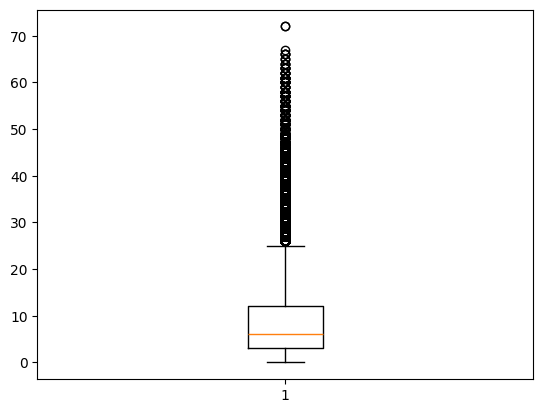

In [48]:
plt.boxplot(df["span"].dropna())
plt.show()

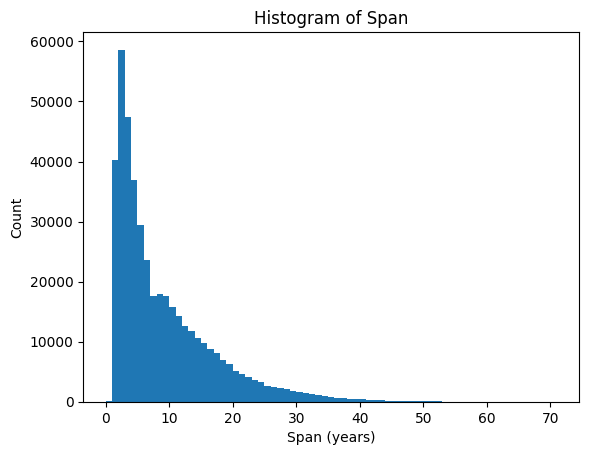

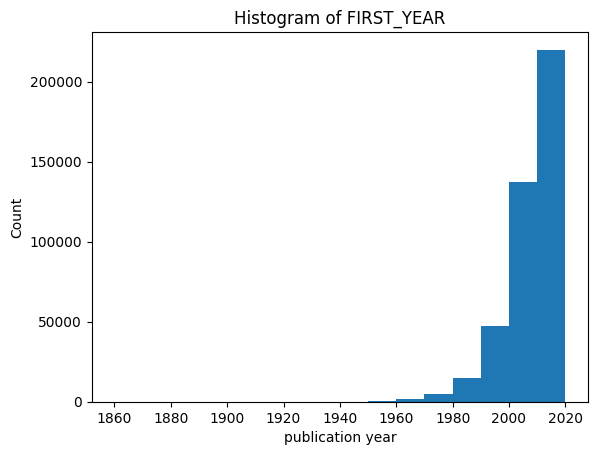

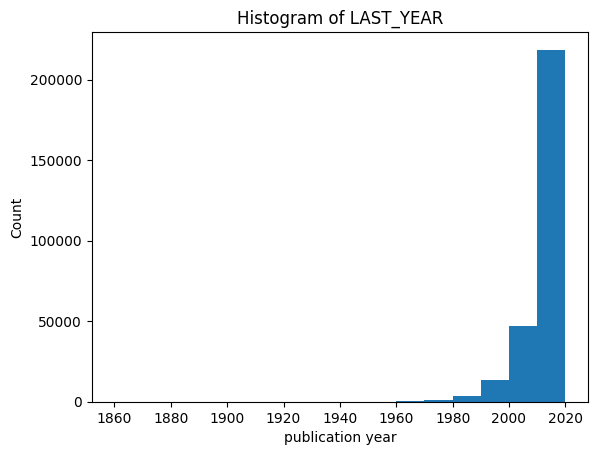

In [63]:
#TASK 2: What is the average publication span (as defined in Task 1) of scientists in this example?


#2 a) Draw histograms of the span number and the two underlying values (FIRST/LAST_YEAR). Choose suitable bins for the x-axis. Briefly explain your choice of bins.

'''
Choosing larger bins means the bars get wider and you lose detail, while choosing smaller bins can make the histogram look too noisy. For the span histogram, we chose a bin size of 1, -> this way each bar represents exactly one year and you can clearly see how many authors were active for a specific number of years.
For FIRST_YEAR and LAST_YEAR, we chose a bin size of 10, since the values range from ~1860 to ~2023. A bin size of 1 would result in too many bars, while a bin size of 10 gives a clear overview of how the publication activity has changed over time.
'''

plt.hist(df["span"], bins=range(0, 72, 1))
plt.title("Histogram of Span")
plt.xlabel("Span (years)")
plt.ylabel("Count")
plt.show()

plt.hist(df["FIRST_YEAR"], bins=range(1860, 2023, 10))
plt.title("Histogram of FIRST_YEAR")
plt.xlabel("publication year")
plt.ylabel("Count")
plt.show()

plt.hist(df["LAST_YEAR"], bins=range(1860, 2023, 10))
plt.title("Histogram of LAST_YEAR")
plt.xlabel("publication year")
plt.ylabel("Count")
plt.show()

In [50]:
#2 b) Determine at least two classes of data rows that need to be filtered out. A class is a set of rows from the CSV file that is discarded because of a common property.

'''
CLASS A:
MOTIVATION:
A span of 0 or less means that the LAST_YEAR is smaller than or equal to the FIRST_YEAR  which is logically impossible, as the formula requires the span to be at least 1. These entries are therefore false data points. In the histogram, this class manifests as a small bar at span = 0.

EXAMPLE: 
Person homepages/194/3750 has FIRST_YEAR = 2019 and LAST_YEAR = 2018, resulting in a span of 0.

INFLUENCE ON RESULT: 
Discarding this class has almost no effect on the mean publication span 
(Mean all data: 8.6109 -> Mean span > 0:  8.6146), as the class is very small (190 out of 438321 entries). However, these entries are still removed as they represent clear data errors.
'''

class_a = df[df["span"] <= 0]
print(f"size class A: {len(class_a)}")
print(class_a.head(3))

'''
CLASS B:
MOTIVATION: 
Computer science as a discipline did not really exist before the 1950s, so any entry with a FIRST_YEAR before 1950 is likely a data error or at least a clear outlier. In the histogram of FIRST_YEAR, it is clearly visible, that there are very few to no publications before the 1950s.

EXAMPLE: 
Person homepages/49/3191 has FIRST_YEAR = 1861 and LAST_YEAR = 1891

INFLUENCE ON THE RESULT: 
Discarding this class also has almost no effect on the mean (Mean all data: 8.6109 -> First_year >= 1950:  8.6101), as the class is very small. 
'''
class_b = df[df["FIRST_YEAR"] < 1950]
print(f"\n size class B: {len(class_b)}")
print(class_b.sort_values("FIRST_YEAR").head(3))

'''
IMPACT OF BOTH CLASSES IN GENERAL: 
The mean does not change drastically by removing those classes, however some other statistical properties do change slightly:

1. Min changes from 0 to 1, which makes sense as we removed all entries with span <= 0.
2. Max changes from 72 to 67, as the oldest outliers (before 1950) are removed.
Median, Q1 and Q3 remain unchanged, showing that the distribution is not affected drastically.

Overall, the answer to the research question (average publication span) is not significantly affected by removing these two classes, since they are too small to have a major impact. However, removing them improves the quality and plausibility of the dataset. The average publication span of scientists in this dataset is 8.6109 years, and 8.6138 years after removing implausible data points. 
'''

size class A: 190
               PERSON_ID  FIRST_YEAR  LAST_YEAR  span
4195  homepages/194/3750      2019.0     2018.0   0.0
4277   homepages/91/6485      2009.0     2008.0   0.0
4278   homepages/91/6485      2009.0     2008.0   0.0

 size class B: 161
                PERSON_ID  FIRST_YEAR  LAST_YEAR  span
407468  homepages/49/3191      1861.0     1891.0  31.0
257927   homepages/31/198      1864.0     1893.0  30.0
195348  homepages/81/6812      1865.0     1872.0   8.0


In [51]:
print(f'Mean all data: {df["span"].mean()}')

a = df[(df["span"] > 0)]
print(f'span > 0: {a["span"].mean()}')

b = df[df["FIRST_YEAR"] >= 1950]
print(f'FIRST_YEAR >= 1950: {b["span"].mean()}')

filtered_both = df[(df["span"] > 0) & (df["FIRST_YEAR"] >= 1950)]
print(f'Mean filtered both: {filtered_both["span"].mean()}')

Mean all data: 8.610909837561598
span > 0: 8.614644055417342
FIRST_YEAR >= 1950: 8.61012554803165
Mean filtered both: 8.613860798367007


In [55]:
print(f'All data: \n {df["span"].describe()}')
print(f'\nFiltered: \n {filtered_both["span"].describe()}')


All data: 
 count    438320.000000
mean          8.610910
std           7.958047
min           0.000000
25%           3.000000
50%           6.000000
75%          12.000000
max          72.000000
Name: span, dtype: float64

Filtered: 
 count    437969.000000
mean          8.613861
std           7.955291
min           1.000000
25%           3.000000
50%           6.000000
75%          12.000000
max          67.000000
Name: span, dtype: float64
